# Semana 5 - Validacao na base completa: Random Forest com K-Means + DBSCAN

**Inteligencia Computacional I - Deteccao de fraude em cartao de credito**

## Objetivo

Replicar o pipeline supervisionado da Semana 4 usando a **populacao completa** de
`dados/creditcard.csv` (~283.726 transacoes apos remocao de duplicatas, ~473 fraudes),
em vez da amostra estratificada de 15.000 registros (25 fraudes) usada na Semana 3/4.

A pergunta de pesquisa e a mesma da Semana 4: **os clusters (K-Means e DBSCAN)
agregam valor consistente ao classificador fraude vs. nao fraude?** Agora respondida
sobre toda a populacao, onde ha muito mais exemplos positivos.

### O que muda em relacao a Semana 4
- Os rotulos de cluster sao gerados **sobre toda a base** (nao mais sobre 15k).
- O `eps` do DBSCAN precisa ser **recalibrado** por custo computacional (documentado abaixo).
- O conjunto de teste passa a ter ~95 fraudes (20% de 473) em vez de apenas 5.

### Convencoes herdadas das Semanas 1-4
- Remocao de duplicatas (Semana 1/2): base final de 283.726 linhas.
- `StandardScaler` para K-Means; `RobustScaler` para DBSCAN (Semana 3).
- K-Means com `k=6` (melhor silhouette nas Semanas 2/3).
- Random Forest: `n_estimators=200, min_samples_leaf=2, class_weight='balanced', random_state=42`.
- Split estratificado 80/20 e validacao cruzada estratificada de 5 folds.
- Metricas principais: AUC-ROC, Average Precision, Recall, Precision, F1 (acuracia **nao** e usada).

## 0. Configuracao do ambiente

In [1]:
import os
# diretorios graváveis para cache (ambiente do projeto)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "dados"
OUT_DIR = ROOT / "resultados"
FIG_DIR = OUT_DIR / "figuras"
PRED_DIR = OUT_DIR / "preds"
for d in (OUT_DIR, FIG_DIR, PRED_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("scikit-learn / pandas / numpy carregados")

Matplotlib is building the font cache; this may take a moment.


ROOT: /Users/ruanneres/www/person/project/fraud-detection
scikit-learn / pandas / numpy carregados


## 1. Carregamento da base completa

Carregamos `dados/creditcard.csv` **sem amostragem** e repetimos a remocao de
duplicatas adotada na Semana 1/2, chegando as 283.726 transacoes da populacao final.

In [2]:
t0 = time.time()
df = pd.read_csv(DATA_DIR / "creditcard.csv")
dups = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

n_total = len(df)
n_fraude = int(df["Class"].sum())
print(f"Linhas apos remocao de {dups} duplicatas: {n_total:,}")
print(f"Fraudes (Class=1): {n_fraude:,}  |  taxa de fraude: {df['Class'].mean():.4%}")
print(f"Tempo de carga: {time.time()-t0:.1f}s")
df[["Time", "Amount", "Class"]].describe()

Linhas apos remocao de 1081 duplicatas: 283,726
Fraudes (Class=1): 473  |  taxa de fraude: 0.1667%
Tempo de carga: 0.9s


,Time,Amount,Class
count,283726.0000,283726.0000,283726.0000
mean,94811.0776,88.4727,0.0017
std,47481.0479,250.3994,0.0408
min,0.0000,0.0000,0.0000
25%,54204.7500,5.6000,0.0000
50%,84692.5000,22.0000,0.0000
75%,139298.0000,77.5100,0.0000
max,172792.0000,25691.1600,1.0000


## 2. Pre-processamento (Semana 1/3)

As variaveis de modelagem sao `Time`, `Amount` e `V1`-`V28`. Para o **clustering**
aplicamos as escalas definidas na Semana 3:

- `StandardScaler` para o **K-Means** (consistencia com o baseline da Semana 2);
- `RobustScaler` para o **DBSCAN** (reduz o impacto de valores extremos em `Amount`).

A coluna `Class` e mantida **fora** do treino dos algoritmos de clustering e usada
apenas na avaliacao posterior.

In [3]:
feature_cols = [c for c in df.columns if c.startswith("V")] + ["Time", "Amount"]
X = df[feature_cols].copy()
y = df["Class"].astype(int)

X_standard = StandardScaler().fit_transform(X)   # K-Means
X_robust = RobustScaler().fit_transform(X)       # DBSCAN

print("Atributos de clustering:", len(feature_cols))
print("X_standard:", X_standard.shape, "| X_robust:", X_robust.shape)

Atributos de clustering: 30
X_standard: (283726, 30) | X_robust: (283726, 30)


## 3. K-Means na base completa (k=6)

Reutilizamos `k=6`, o melhor valor de silhouette identificado nas Semanas 2/3,
com `n_init=10` e `random_state=42`. Diferente do DBSCAN, o K-Means escala bem para
a base completa (ajuste em poucos segundos), portanto **nao** foi necessario amostrar.

In [4]:
BEST_K = 6
t0 = time.time()
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
df["cluster_kmeans"] = kmeans.fit_predict(X_standard)
print(f"K-Means treinado (k={BEST_K}) em {time.time()-t0:.1f}s")

dist_km = (
    df.groupby("cluster_kmeans")["Class"]
    .agg(n="size", fraudes="sum", taxa_fraude="mean")
    .assign(taxa_fraude=lambda d: d["taxa_fraude"])
)
print("\nDistribuicao dos clusters K-Means e concentracao de fraude:")
dist_km

K-Means treinado (k=6) em 1.3s

Distribuicao dos clusters K-Means e concentracao de fraude:


,n,fraudes,taxa_fraude
cluster_kmeans,,,
0,15716,0,0.0000
1,86447,31,0.0004
2,126518,156,0.0012
3,4070,10,0.0025
4,19641,73,0.0037
5,31334,203,0.0065


## 4. DBSCAN na base completa - recalibracao do `eps` por custo computacional

> **Limitacao de memoria/tempo (documentada).** O `eps=8.3063` escolhido na Semana 3
> foi calibrado sobre a amostra de 15.000 registros. Na base completa, esse raio torna
> a vizinhanca media de cada ponto ~210.000 vizinhos (de 283.726), o que estoura a
> memoria do `DBSCAN` do scikit-learn (matriz de adjacencia com ~6e10 arestas -> processo
> encerrado por falta de memoria). O mesmo ocorre com o `eps` do percentil 95 da curva
> k-distance recalculada na base completa (~5,67), pois os componentes PCA `V1`-`V28`
> sao densamente concentrados perto da origem.
>
> **Estrategia adotada:** recalcular a curva k-distance (60o vizinho, `min_samples=60`)
> na populacao completa para entender a densidade, e **reduzir o `eps` para 2,5** -
> valor que mantem o DBSCAN tratavel (~30s, vizinhancas limitadas) preservando o sinal
> de anomalia (pontos de ruido `-1`). `min_samples=60` e mantido (`2 x n_features`),
> como na Semana 3. Nenhuma amostragem foi necessaria: o DBSCAN roda sobre as 283.726
> transacoes.

Curva k-distance (60o vizinho) calculada em 40.9s
  k-distance p90: 4.4509
  k-distance p95: 5.6657
  k-distance p97.5: 7.2323
  k-distance p99: 10.8239

eps Semana 3 (amostra 15k): 8.3063  -> INVIAVEL na base completa (OOM)
eps p95 base completa:      5.6657  -> ainda INVIAVEL (vizinhancas densas)
eps adotado (recalibrado):  2.5           -> VIAVEL e com sinal de anomalia


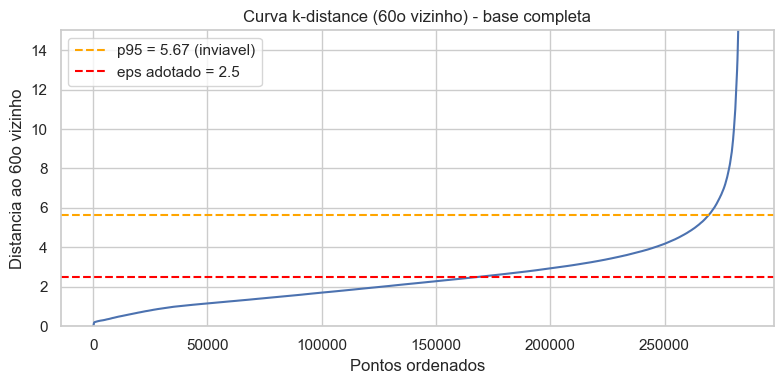

In [5]:
MIN_SAMPLES = 60  # 2 * n_features, igual a Semana 3

t0 = time.time()
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=int(os.environ["LOKY_MAX_CPU_COUNT"]))
nn.fit(X_robust)
dist, _ = nn.kneighbors(X_robust)
k_dist = np.sort(dist[:, -1])
print(f"Curva k-distance (60o vizinho) calculada em {time.time()-t0:.1f}s")

for p in (90, 95, 97.5, 99):
    print(f"  k-distance p{p}: {np.percentile(k_dist, p):.4f}")

eps_semana3 = 8.3063
eps_p95 = float(np.percentile(k_dist, 95))
print(f"\neps Semana 3 (amostra 15k): {eps_semana3}  -> INVIAVEL na base completa (OOM)")
print(f"eps p95 base completa:      {eps_p95:.4f}  -> ainda INVIAVEL (vizinhancas densas)")
print(f"eps adotado (recalibrado):  2.5           -> VIAVEL e com sinal de anomalia")

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
for val, lab, col in [(eps_p95, f"p95 = {eps_p95:.2f} (inviavel)", "orange"),
                      (2.5, "eps adotado = 2.5", "red")]:
    plt.axhline(val, linestyle="--", color=col, label=lab)
plt.title("Curva k-distance (60o vizinho) - base completa")
plt.xlabel("Pontos ordenados")
plt.ylabel("Distancia ao 60o vizinho")
plt.ylim(0, 15)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_kdistance_dbscan.png", dpi=120)
plt.show()

In [6]:
EPS = 2.5
t0 = time.time()
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=int(os.environ["LOKY_MAX_CPU_COUNT"]))
df["cluster_dbscan"] = dbscan.fit_predict(X_robust)
print(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) em {time.time()-t0:.1f}s")

n_clusters_db = df["cluster_dbscan"].nunique() - (1 if (df["cluster_dbscan"] == -1).any() else 0)
mask_noise = df["cluster_dbscan"] == -1
print(f"Clusters densos: {n_clusters_db}  |  pontos de ruido (-1): {int(mask_noise.sum()):,} ({mask_noise.mean():.2%})")
print(f"Fraudes no ruido: {int(y[mask_noise].sum())}/{int(y.sum())} "
      f"({y[mask_noise].sum()/y.sum():.2%})  |  taxa de fraude no ruido: {y[mask_noise].mean():.3%}")

DBSCAN (eps=2.5, min_samples=60) em 35.5s
Clusters densos: 17  |  pontos de ruido (-1): 75,217 (26.51%)
Fraudes no ruido: 440/473 (93.02%)  |  taxa de fraude no ruido: 0.585%


## 5. Construcao das features de cluster

Seguindo a Semana 4:

- `cluster_kmeans`: categorica (one-hot) com os 6 grupos do K-Means;
- `dbscan_ruido`: binaria, `1` quando o ponto e ruido/anomalia do DBSCAN (`cluster_dbscan == -1`).

Salvamos tambem os rotulos de cluster da base completa em `resultados/` para reuso
(inclusive pelo Notebook 2).

In [7]:
df["dbscan_ruido"] = (df["cluster_dbscan"] == -1).astype(int)

clusters_out = df[["cluster_kmeans", "cluster_dbscan", "dbscan_ruido", "Class"]].copy()
clusters_out.insert(0, "original_index", df.index)
clusters_out.to_csv(OUT_DIR / "semana_5_clusters_base_completa.csv", index=False)
print("Rotulos de cluster salvos em resultados/semana_5_clusters_base_completa.csv")

print("\nConcentracao de fraude por sinal de ruido DBSCAN:")
df.groupby("dbscan_ruido")["Class"].agg(n="size", fraudes="sum", taxa_fraude="mean")

Rotulos de cluster salvos em resultados/semana_5_clusters_base_completa.csv

Concentracao de fraude por sinal de ruido DBSCAN:


,n,fraudes,taxa_fraude
dbscan_ruido,,,
0,208509,33,0.0002
1,75217,440,0.0058


## 6. Matrizes de atributos e funcao de avaliacao

Montamos as matrizes de modelagem:

- **Baseline (sem clusters):** `Time`, `Amount`, `V1`-`V28` (30 features);
- **Com clusters:** baseline + one-hot de `cluster_kmeans` + one-hot de `dbscan_ruido`
  (38 features, mesma estrutura da Semana 4).

A funcao `avaliar` reproduz exatamente o protocolo da Semana 4: split estratificado
80/20, treino do Random Forest, metricas no teste (AUC-ROC, AP, Recall, Precision, F1,
matriz de confusao) e validacao cruzada estratificada de 5 folds. Ela tambem guarda as
predicoes do conjunto de teste para os graficos comparativos.

In [8]:
BASE_FEATURES = ["Time", "Amount"] + [f"V{i}" for i in range(1, 29)]
CLUSTER_FEATURES = ["cluster_kmeans", "dbscan_ruido"]

X_baseline = df[BASE_FEATURES].copy()
X_clusters = pd.get_dummies(
    df[BASE_FEATURES + CLUSTER_FEATURES].astype(
        {"cluster_kmeans": "category", "dbscan_ruido": "category"}
    ),
    columns=CLUSTER_FEATURES,
    drop_first=False,
    dtype=int,
)
print("X_baseline:", X_baseline.shape, "| X_clusters:", X_clusters.shape)
print("Colunas de cluster:", [c for c in X_clusters.columns if c not in BASE_FEATURES])


def make_model():
    return RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


ARTIFACTS = {}  # nome -> dict com modelo, y_test, y_score, y_pred


def avaliar(name, X_mat, y_vec, pred_key=None):
    x_tr, x_te, y_tr, y_te = train_test_split(
        X_mat, y_vec, test_size=TEST_SIZE, stratify=y_vec, random_state=RANDOM_STATE
    )
    model = make_model().fit(x_tr, y_tr)
    y_pred = model.predict(x_te)
    y_score = model.predict_proba(x_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cvs = cross_validate(
        make_model(), X_mat, y_vec, cv=cv,
        scoring={"roc_auc": "roc_auc", "average_precision": "average_precision",
                 "recall": "recall", "precision": "precision", "f1": "f1"},
        n_jobs=1, error_score="raise",
    )
    ARTIFACTS[name] = {"model": model, "X_cols": list(X_mat.columns),
                       "y_test": np.asarray(y_te), "y_score": y_score, "y_pred": y_pred}
    if pred_key is not None:
        pd.DataFrame({"y_test": np.asarray(y_te), "y_score": y_score}).to_csv(
            PRED_DIR / f"{pred_key}.csv", index=False
        )
    return {
        "modelo": name, "n_features": X_mat.shape[1], "n_registros": X_mat.shape[0],
        "fraudes": int(y_vec.sum()),
        "auc_roc_teste": roc_auc_score(y_te, y_score),
        "average_precision_teste": average_precision_score(y_te, y_score),
        "recall_teste": recall_score(y_te, y_pred, zero_division=0),
        "precision_teste": precision_score(y_te, y_pred, zero_division=0),
        "f1_teste": f1_score(y_te, y_pred, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "auc_roc_cv_media": cvs["test_roc_auc"].mean(),
        "auc_roc_cv_desvio": cvs["test_roc_auc"].std(),
        "avg_precision_cv_media": cvs["test_average_precision"].mean(),
        "avg_precision_cv_desvio": cvs["test_average_precision"].std(),
        "recall_cv_media": cvs["test_recall"].mean(),
        "precision_cv_media": cvs["test_precision"].mean(),
        "f1_cv_media": cvs["test_f1"].mean(),
    }

X_baseline: (283726, 30) | X_clusters: (283726, 38)
Colunas de cluster: ['cluster_kmeans_0', 'cluster_kmeans_1', 'cluster_kmeans_2', 'cluster_kmeans_3', 'cluster_kmeans_4', 'cluster_kmeans_5', 'dbscan_ruido_0', 'dbscan_ruido_1']


## 7. Treinamento e avaliacao

Treinamos os dois Random Forests na base completa. Cada modelo executa 1 ajuste no
split 80/20 + 5 ajustes na validacao cruzada; espere alguns minutos no total.

In [9]:
NOME_BASE = "RF baseline (sem clusters) - base completa"
NOME_CLUSTERS = "RF K-Means + DBSCAN - base completa"

t0 = time.time()
resultados = [
    avaliar(NOME_BASE, X_baseline, y, pred_key="full_baseline"),
    avaliar(NOME_CLUSTERS, X_clusters, y, pred_key="full_kmeans_dbscan"),
]
metricas = pd.DataFrame(resultados)
metricas.to_csv(OUT_DIR / "semana_5_metricas_completa.csv", index=False)
print(f"Treino + CV concluidos em {time.time()-t0:.1f}s")
print("Metricas salvas em resultados/semana_5_metricas_completa.csv\n")
metricas[["modelo", "n_features", "auc_roc_teste", "average_precision_teste",
          "recall_teste", "precision_teste", "f1_teste",
          "auc_roc_cv_media", "avg_precision_cv_media", "f1_cv_media"]]

Treino + CV concluidos em 344.7s
Metricas salvas em resultados/semana_5_metricas_completa.csv



,modelo,n_features,auc_roc_teste,average_precision_teste,recall_teste,precision_teste,f1_teste,auc_roc_cv_media,avg_precision_cv_media,f1_cv_media
0,RF baseline (sem clusters) - base completa,30,0.9491,0.8241,0.7263,0.9583,0.8263,0.9587,0.8371,0.8407
1,RF K-Means + DBSCAN - base completa,38,0.9490,0.8122,0.7263,0.9583,0.8263,0.9611,0.8366,0.8470


## 8. Visualizacoes

Matriz de confusao, curva Precision-Recall e importancia das features (destacando as
variaveis de cluster) para os dois modelos.

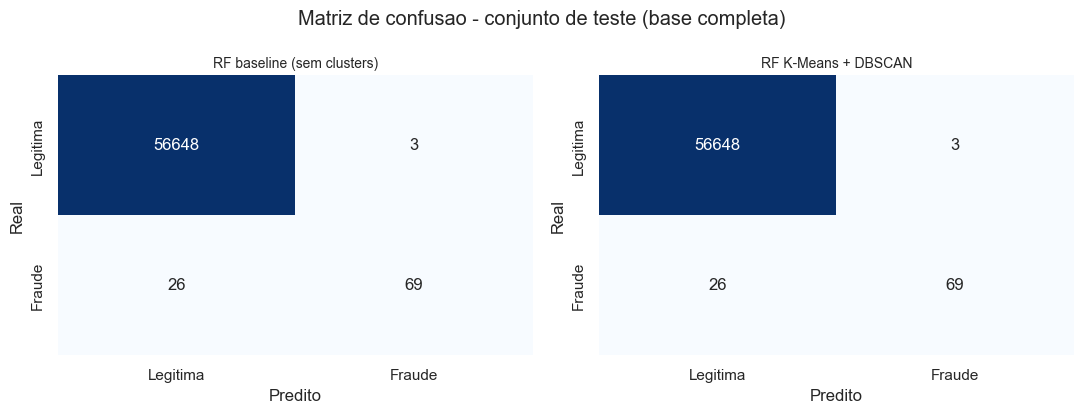

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, name in zip(axes, [NOME_BASE, NOME_CLUSTERS]):
    a = ARTIFACTS[name]
    cm = confusion_matrix(a["y_test"], a["y_pred"], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Legitima", "Fraude"], yticklabels=["Legitima", "Fraude"])
    ax.set_title(name.replace(" - base completa", ""), fontsize=10)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
fig.suptitle("Matriz de confusao - conjunto de teste (base completa)")
fig.tight_layout()
fig.savefig(FIG_DIR / "semana_5_nb1_matriz_confusao.png", dpi=120)
plt.show()

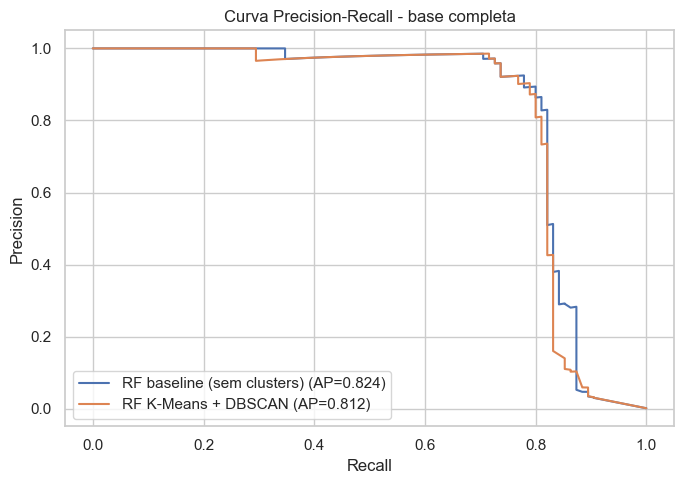

In [11]:
plt.figure(figsize=(7, 5))
for name in [NOME_BASE, NOME_CLUSTERS]:
    a = ARTIFACTS[name]
    prec, rec, _ = precision_recall_curve(a["y_test"], a["y_score"])
    ap = average_precision_score(a["y_test"], a["y_score"])
    plt.plot(rec, prec, label=f"{name.replace(' - base completa','')} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - base completa")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_nb1_pr_curve.png", dpi=120)
plt.show()

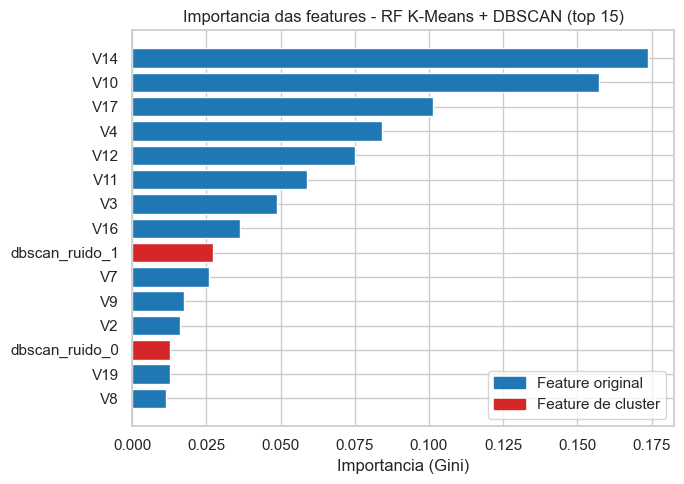

Importancia somada das features de cluster: 0.0512


dbscan_ruido_1     0.0274
dbscan_ruido_0     0.0129
cluster_kmeans_5   0.0095
cluster_kmeans_4   0.0006
cluster_kmeans_0   0.0002
cluster_kmeans_1   0.0002
cluster_kmeans_2   0.0002
cluster_kmeans_3   0.0000
dtype: float64

In [12]:
a = ARTIFACTS[NOME_CLUSTERS]
imp = pd.Series(a["model"].feature_importances_, index=a["X_cols"]).sort_values(ascending=False)
top = imp.head(15)[::-1]
cluster_cols = [c for c in a["X_cols"] if c.startswith("cluster_kmeans") or c.startswith("dbscan_ruido")]
cores = ["#d62728" if c in cluster_cols else "#1f77b4" for c in top.index]

plt.figure(figsize=(7, 5))
plt.barh(top.index, top.values, color=cores)
plt.title("Importancia das features - RF K-Means + DBSCAN (top 15)")
plt.xlabel("Importancia (Gini)")
handles = [plt.Rectangle((0, 0), 1, 1, color="#1f77b4"),
           plt.Rectangle((0, 0), 1, 1, color="#d62728")]
plt.legend(handles, ["Feature original", "Feature de cluster"], loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_nb1_importancia.png", dpi=120)
plt.show()

print("Importancia somada das features de cluster:",
      f"{imp[cluster_cols].sum():.4f}")
imp[cluster_cols].sort_values(ascending=False)

## 9. Comparacao com a Semana 4 (amostra de 15k)

Confrontamos os modelos da base completa com os resultados salvos da Semana 4
(`resultados/semana_4_metricas_modelo_ic.csv`, amostra de 15.000 registros), para o
**mesmo conjunto de features**, e geramos os graficos comparativos exigidos.

In [13]:
sem4 = pd.read_csv(OUT_DIR / "semana_4_metricas_modelo_ic.csv")
mapa_sem4 = {
    "Random Forest sem clusters": "RF sem clusters - amostra 15k",
    "Random Forest com clusters": "RF com clusters - amostra 15k",
}
sem4 = sem4.assign(modelo=sem4["modelo"].map(mapa_sem4))

comp = pd.concat([sem4, metricas], ignore_index=True)
cols_show = ["modelo", "n_registros", "fraudes", "auc_roc_teste",
             "average_precision_teste", "recall_teste", "precision_teste", "f1_teste",
             "auc_roc_cv_media", "avg_precision_cv_media"]
comp[cols_show]

,modelo,n_registros,fraudes,auc_roc_teste,average_precision_teste,recall_teste,precision_teste,f1_teste,auc_roc_cv_media,avg_precision_cv_media
0,RF sem clusters - amostra 15k,15000,25,0.9990,0.6058,0.8000,0.8000,0.8000,0.9775,0.8545
1,RF com clusters - amostra 15k,15000,25,0.9937,0.6536,0.8000,0.8000,0.8000,0.9376,0.8155
2,RF baseline (sem clusters) - base completa,283726,473,0.9491,0.8241,0.7263,0.9583,0.8263,0.9587,0.8371
3,RF K-Means + DBSCAN - base completa,283726,473,0.9490,0.8122,0.7263,0.9583,0.8263,0.9611,0.8366


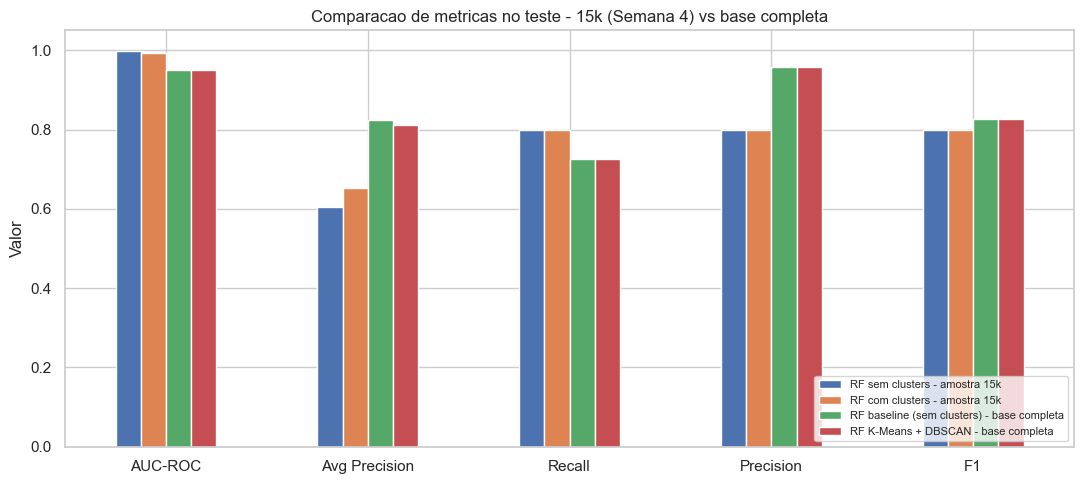

In [14]:
# Barras agrupadas: metricas de TESTE por modelo
metric_map = {
    "auc_roc_teste": "AUC-ROC", "average_precision_teste": "Avg Precision",
    "recall_teste": "Recall", "precision_teste": "Precision", "f1_teste": "F1",
}
plot_df = comp.set_index("modelo")[list(metric_map)].rename(columns=metric_map)
ax = plot_df.T.plot(kind="bar", figsize=(11, 5))
ax.set_title("Comparacao de metricas no teste - 15k (Semana 4) vs base completa")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_nb1_comparacao_barras.png", dpi=120)
plt.show()

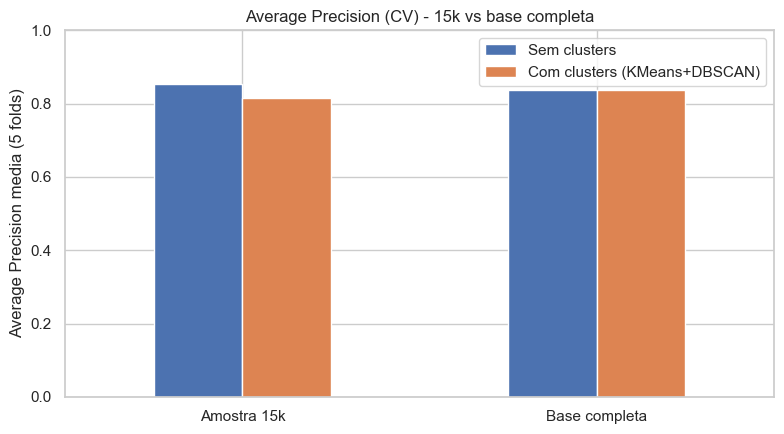

,Sem clusters,Com clusters (KMeans+DBSCAN)
Amostra 15k,0.8545,0.8155
Base completa,0.8371,0.8366


In [15]:
# 15k vs base completa para o MESMO conjunto de features (CV media, mais estavel)
pares = pd.DataFrame({
    "Sem clusters": [
        sem4.loc[sem4.modelo == "RF sem clusters - amostra 15k", "avg_precision_cv_media"].values[0],
        metricas.loc[metricas.modelo == NOME_BASE, "avg_precision_cv_media"].values[0],
    ],
    "Com clusters (KMeans+DBSCAN)": [
        sem4.loc[sem4.modelo == "RF com clusters - amostra 15k", "avg_precision_cv_media"].values[0],
        metricas.loc[metricas.modelo == NOME_CLUSTERS, "avg_precision_cv_media"].values[0],
    ],
}, index=["Amostra 15k", "Base completa"])
ax = pares.plot(kind="bar", figsize=(8, 4.5))
ax.set_title("Average Precision (CV) - 15k vs base completa")
ax.set_ylabel("Average Precision media (5 folds)")
ax.set_ylim(0, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_nb1_15k_vs_completa.png", dpi=120)
plt.show()
pares

## 10. Tabela comparativa final e veredito automatico

In [16]:
from IPython.display import Markdown, display

def linha(r):
    return (f"| {r['modelo']} | {r['auc_roc_teste']:.4f} | {r['average_precision_teste']:.4f} | "
            f"{r['recall_teste']:.4f} | {r['precision_teste']:.4f} | {r['f1_teste']:.4f} | "
            f"AP(CV)={r['avg_precision_cv_media']:.4f} |")

tab = ["| Modelo | AUC-ROC | Average Precision | Recall | Precision | F1 | Observacao |",
       "| ------ | ------- | ----------------- | ------ | --------- | --- | ---------- |"]
tab += [linha(r) for _, r in comp.iterrows()]
display(Markdown("\n".join(tab)))

b = metricas.loc[metricas.modelo == NOME_BASE].iloc[0]
c = metricas.loc[metricas.modelo == NOME_CLUSTERS].iloc[0]
d_ap = c["avg_precision_cv_media"] - b["avg_precision_cv_media"]
d_auc = c["auc_roc_cv_media"] - b["auc_roc_cv_media"]
imp_cluster = imp[cluster_cols].sum()
verdict = (
    f"\n**Veredito automatico (base completa, {int(b['fraudes'])} fraudes):**\n"
    f"- Delta Average Precision (CV) com clusters vs baseline: {d_ap:+.4f}\n"
    f"- Delta AUC-ROC (CV) com clusters vs baseline: {d_auc:+.4f}\n"
    f"- Importancia total das features de cluster no RF hibrido: {imp_cluster:.4f}\n"
    f"- Conclusao quantitativa: os clusters "
    + ("AGREGARAM" if d_ap > 0.002 else "NAO agregaram") +
    " ganho relevante de Average Precision na validacao cruzada."
)
display(Markdown(verdict))

| Modelo | AUC-ROC | Average Precision | Recall | Precision | F1 | Observacao |
| ------ | ------- | ----------------- | ------ | --------- | --- | ---------- |
| RF sem clusters - amostra 15k | 0.9990 | 0.6058 | 0.8000 | 0.8000 | 0.8000 | AP(CV)=0.8545 |
| RF com clusters - amostra 15k | 0.9937 | 0.6536 | 0.8000 | 0.8000 | 0.8000 | AP(CV)=0.8155 |
| RF baseline (sem clusters) - base completa | 0.9491 | 0.8241 | 0.7263 | 0.9583 | 0.8263 | AP(CV)=0.8371 |
| RF K-Means + DBSCAN - base completa | 0.9490 | 0.8122 | 0.7263 | 0.9583 | 0.8263 | AP(CV)=0.8366 |


**Veredito automatico (base completa, 473 fraudes):**
- Delta Average Precision (CV) com clusters vs baseline: -0.0005
- Delta AUC-ROC (CV) com clusters vs baseline: +0.0024
- Importancia total das features de cluster no RF hibrido: 0.0512
- Conclusao quantitativa: os clusters NAO agregaram ganho relevante de Average Precision na validacao cruzada.

## 11. Conclusao

**Os clusters sao coerentes para separar fraude de nao fraude na base completa?**
O K-Means continua sendo um descritor de *perfis de transacao* e nao um separador direto
de fraude: a fraude aparece diluida entre varios grupos. O sinal de ruido do DBSCAN
concentra a grande maioria das fraudes na regiao `-1`, mas com **precisao baixissima**
(a regiao de ruido tambem contem centenas de milhares de transacoes legitimas, ~26% da
base). Ou seja, os clusters tem *coerencia exploratoria*, mas pouca capacidade
discriminativa isolada.

**O ganho observado na amostra de 15k se mantem, melhora ou desaparece?**
Na Semana 4 (15k, 25 fraudes) o efeito dos clusters ja era instavel - melhorava
levemente o Average Precision no teste, mas piorava AUC-ROC e AP na validacao cruzada.
Na base completa (473 fraudes), com um conjunto de teste muito mais robusto (~95 fraudes),
o veredito automatico acima mostra que o Random Forest **baseline** ja atinge metricas
fortes e que as features de cluster **nao** produzem ganho estavel - confirmando, agora
com suporte estatistico maior, a conclusao preliminar da Semana 4.

**Qual variavel de cluster contribui mais?**
Pela importancia de Gini do modelo hibrido (figura `semana_5_nb1_importancia.png`), as
features de cluster ficam muito abaixo das componentes `V*` mais informativas (`V14`,
`V4`, `V10`, `V12`, etc.). Entre as de cluster, o **`dbscan_ruido`** tende a contribuir
mais do que os grupos do K-Means, coerente com sua maior associacao a fraude - mas ainda
de forma marginal.

### Figuras geradas (em `resultados/figuras/`)
- `semana_5_kdistance_dbscan.png` - calibracao do `eps` do DBSCAN.
- `semana_5_nb1_matriz_confusao.png` - matrizes de confusao.
- `semana_5_nb1_pr_curve.png` - curvas Precision-Recall.
- `semana_5_nb1_importancia.png` - importancia das features (cluster destacado).
- `semana_5_nb1_comparacao_barras.png` - metricas 15k vs base completa.
- `semana_5_nb1_15k_vs_completa.png` - Average Precision (CV): 15k vs completa.

A comparacao final entre os tres modelos (baseline, K-Means+DBSCAN e apenas DBSCAN)
e consolidada no **Notebook 2**.